# Visual Wake Words

<p align="right">
Run Time: ~10 minutes
</p>

This notebook walks through benchmarking a model on the **Visual Wake Words** dataset,
targeting Akida 1 hardware.

For details on the dataset and preparation of the model, see the neighbouring README.md
and vww_notebook_training.ipynb.

## Model

A pretrained Akida model is included in this repo, at 
`pretrained_models/akidanet_vww_qat.fbz`. As with all model files in the repo, 
that is handled via `git-lfs` (for efficient large file storage). If you haven't set that 
up yet, see the [Trained models](../../../README.md#trained-models) section of the 
top-level README.

If you have run through the training scripts or notebook, and prefer to benchmark the 
Akida model generated through that, simply modify the model directory and filename in the
following cell:

In [1]:
import akida
import os
import numpy as np

from tqdm import tqdm

os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '1')

DATA_PATH = './data/vw_coco2014_96'
MODELS_DIR = './pretrained_models/'
MODEL_FILENAME = 'akidanet_vww_qat.fbz'
akida_model_path = os.path.join(MODELS_DIR, MODEL_FILENAME)

SEED = 42

To load the model, we simply have to pass the path to the `.fbz` file to the `akida.Model()`
method:

In [2]:
# Load the Akida model
akida_model = akida.Model(akida_model_path)

## Dataset

`get_data` returns a training and a validation `tf.data.Dataset`. The full
preprocessing and augmentation code is in [vww_data.py](vww_data.py) —
standard tf_keras pipeline code, not described further here.

Images are resized from variable original sizes to **96 × 96 RGB** and delivered as pixel values 
in the uint8 range (0–255).

In [3]:
from vww_data import get_data

BATCH_SIZE = 32
INPUT_SHAPE = (96, 96, 3)

train_ds, val_ds = get_data(DATA_PATH, INPUT_SHAPE, BATCH_SIZE, seed=SEED)

2026-10-09 13:25:40.937067: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1791545140.950426  577419 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1791545140.954566  577419 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1791545140.964619  577419 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1791545140.964635  577419 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1791545140.964637  577419 computation_placer.cc:177] computation placer alr

Found 98658 images belonging to 2 classes.


Found 10961 images belonging to 2 classes.


## Evaluation of Akida Model

We now run evaluation through the Akida model, to check that accuracy is 
comparable to that obtained from the quantized tf_keras model. If an Akida 1
hardware device is connected, it will be used for inference; if not, the
code will fall back to using the software backend: this delivers a
bit-accurate simulation of the results that will be obtained when running
the model on hardware. Let's run that check before going any further

### Check for a connected Akida hardware device

We can use the `akida.devices()` function to detect connected hardware devices.
That returns a list - if it's empty, there were no hardware devices. Otherwise, 
typically we'd only have a single Akida device connected on a given machine, 
and we can just select the first (and only) device returned.

In [4]:
devices = akida.devices()
if len(devices)>0:
    # Hardware is available
    device = devices[0]
else:
    # Hardware is not available
    device = None

In the present case, we want to be a bit more careful and ensure that the
device is the right version for the model we want to test (here, Akida IP
version 1). We'll import a local function to do that - check out the details 
if interested

In [5]:
from brainchip_utils.hardware_utils import get_akida_device

# Look for a matching hardware device
device = get_akida_device(target_version = akida_model.ip_version)
if device is not None:
    akida_model.map(device, mode=akida.MapMode.Minimal, hw_only=True)

Target Akida device found


### Run Evaluation on Akida

The Akida runtime cannot consume `tf.data.Dataset` objects directly. Rather
it expects a 4D numpy array (n, h, w, c) in uint8 format, so we
iterate over test batches manually. Obviously that situation arises because
the dataset is acquired here in tensorflow format. In a more representative
deployment situation, images would be acquired and sent to Akida without
ever going via the tensorflow dataset format.

The model output tensor has shape `(B, 1, 1, C)` which is squeezed to 
`(B, C)` before taking the class argmax.


In [6]:
labels_all = []
logits_all = []
num_batches = len(val_ds)
val_ds.reset() # Ensure a clean run through the full validation dataset
for _ in tqdm(range(num_batches), desc="Evaluating on Akida"):
    batch, label_batch = next(val_ds)
    if not isinstance(batch, np.ndarray):
        batch = batch.numpy()

    logits_batch = akida_model.predict(batch.astype(np.uint8))

    logits_batch = logits_batch.squeeze(axis=(1, 2))
    labels_all.append(label_batch)
    logits_all.append(logits_batch)

labels_all = np.concatenate(labels_all)
logits_all = np.concatenate(logits_all)
preds = np.argmax(logits_all, axis=1)

akida_accuracy = float(np.mean(preds == np.array(labels_all)))
print(f'Akida accuracy: {akida_accuracy:.4f}')

Evaluating on Akida:   0%|          | 0/343 [00:00<?, ?it/s]

Evaluating on Akida:   1%|          | 2/343 [00:00<00:20, 16.89it/s]

Evaluating on Akida:   1%|          | 4/343 [00:00<00:19, 17.77it/s]

Evaluating on Akida:   2%|▏         | 6/343 [00:00<00:18, 18.09it/s]

Evaluating on Akida:   2%|▏         | 8/343 [00:00<00:18, 18.26it/s]

...

Evaluating on Akida:  99%|█████████▊| 338/343 [00:18<00:00, 18.47it/s]

Evaluating on Akida:  99%|█████████▉| 340/343 [00:18<00:00, 18.47it/s]

Evaluating on Akida: 100%|█████████▉| 342/343 [00:18<00:00, 18.48it/s]

Evaluating on Akida: 100%|██████████| 343/343 [00:18<00:00, 18.54it/s]

Akida accuracy: 0.8842


### Activation Sparsity

Akida hardware skips computation for zero-valued activations, so activation
sparsity directly reduces both energy consumption and inference latency.
Below we measure per-layer sparsity on a 1024-sample calibration batch drawn
from the training set.

In [7]:
from akida_models.sparsity import compute_sparsity
from brainchip_utils.plot_utils import pretty_print_sparsity
from vww_data import get_samples

NUM_SAMPLES=1024
samples = get_samples(DATA_PATH, INPUT_SHAPE, num_samples=NUM_SAMPLES)
sparsity_dict = compute_sparsity(akida_model, samples=samples)
pretty_print_sparsity(sparsity_dict)

2026-10-09 13:26:03.438985: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 109619 images belonging to 2 classes.



Layer            Sparsity
-------------------------
conv_0            23.86%
conv_1            37.03%
conv_2            56.00%
conv_3            40.28%
separable_4       33.30%
separable_5       65.21%
separable_6       40.46%
separable_7       48.44%
separable_8       60.60%
separable_9       65.68%
separable_10      74.43%
separable_11      59.27%
separable_12      89.35%
separable_13      89.25%
predictions        0.50%
-------------------------
Mean              52.24%


## Hardware Benchmarking

**These cells require a physical AKD1500 device to be connected.** If `device is
None` (reported in the evaluation section above), skip ahead to the Summary.

Akida is an event-driven architecture: computations scale with the number of
non-zero activations, not with tensor size. That means benchmark results are
*input-dependent* — random or synthetic data would give artificially fast or
slow timings. The `samples` array loaded above (real images from the training
split) is therefore the correct input to use here.

### Simple Benchmark

The simplest way to time an Akida model is to call `forward` in a loop and
read back two clocks after each inference:

- **System clock** (`time.perf_counter_ns`) — wall time including Python and
  USB/PCIe transfer overhead.
- **On-chip clock** (`akida_model.metrics['inference_clk']`) — raw clock cycles
  counted by the AKD1500 itself. Dividing by the 400 MHz core frequency gives
  the pure compute time.

The two numbers should agree closely; a large divergence would indicate a
transfer or driver bottleneck.

In [8]:
import time

CLOCK_FREQUENCY = 400e6  # 400 MHz for AKD1500

if device is not None:
    akida_model.map(device, mode=akida.MapMode.Minimal, hw_only=True)

    # Run a priming frame, so that the model is loaded to the device
    # and the subsequent benchmarking reflects inference time only
    akida_model.forward(samples[:2])
    
    inf_clks = []
    inf_times = []
    for i in range(len(samples)):
        start_t = time.perf_counter_ns()
        akida_model.forward(samples[i:i+1])
        inf_times.append(time.perf_counter_ns() - start_t)
        inf_clks.append(akida_model.metrics['inference_clk'])

    mean_inf_clk = np.mean(inf_clks) / CLOCK_FREQUENCY * 1e3  # cycles → ms
    mean_inf_time = np.mean(inf_times) * 1e-6                  # ns → ms
    print(f'Mean inference time (system clock):      {mean_inf_time:.3f} ms')
    print(f'Mean on-chip time (chip clock cycles):   {mean_inf_clk:.3f} ms')

Mean inference time (system clock):      8.104 ms
Mean on-chip time (chip clock cycles):   8.024 ms


### Full Model Benchmark

The loop above is clear, but it misses two things: power consumption and a
comparison between mapping modes. `full_model_benchmark` from
[brainchip_utils/hardware_utils.py](../../../brainchip_utils/hardware_utils.py)
runs the same timed loop while also coordinating optional INA219 power
measurement in a separate process. It sweeps both `MapMode.Minimal` (fewest
NPs, lowest power) and `MapMode.AllNps` (all NPs, maximum parallelism) so the
trade-off is visible. The multiprocessing and power-meter wiring are
non-trivial and not of interest to most users — consult the source if needed.

In [9]:
from brainchip_utils.hardware_utils import full_model_benchmark, get_mapping_stats
from brainchip_utils.plot_utils import plot_full_model_results

if device is not None:
    map_modes = ['Minimal', 'AllNps']
    POWER_REPEATS = 10
    full_results = {}
    for mm in map_modes:
        map_mode = getattr(akida.MapMode, mm)
        print(f'Running full-model benchmark (MapMode={mm}, {POWER_REPEATS} repeat(s))...')
        full_results[mm] = full_model_benchmark(
            akida_model, device, samples, map_mode=map_mode, repeats=POWER_REPEATS)

        akida_model.map(device, mode=map_mode)
        num_nps, num_passes, num_sequences = get_mapping_stats(akida_model)
        full_results[mm]['num_nps'] = num_nps
        full_results[mm]['num_passes'] = num_passes
        print(f'  Mapping: {num_nps} NP(s), {num_passes} pass(es), {num_sequences} sequence(s)')
        if num_sequences > 1:
            print('WARNING: model not completely mapped to hardware')

Running full-model benchmark (MapMode=Minimal, 10 repeat(s))...
Checking I2C power measurement hardware...
  I2C INA sensor detected — power measurement enabled.


  Supply voltage: 0.805 V

  Power measurement active.
  Repeat 1/10: recording floor (1.0 s)...


  Repeat 1/10 done.
  Repeat 2/10: recording floor (1.0 s)...


  Repeat 2/10 done.
  Repeat 3/10: recording floor (1.0 s)...


...

  Repeat 7/10 done.
  Repeat 8/10: recording floor (1.0 s)...


  Repeat 8/10 done.
  Repeat 9/10: recording floor (1.0 s)...


  Repeat 9/10 done.
  Repeat 10/10: recording floor (1.0 s)...


  Power process: 4749 ok, 0 errors

  Repeat 10/10 done.

  Mean inference time:    5.651 ms  (σ=0.100 ms)
  Mean on-chip time:      5.569 ms  (2227427 clocks)
  Total inferences run:   10240
  Avg dynamic power:      36.0 mW
  Avg dynamic energy:     0.204 mJ/inf
  Mapping: 29 NP(s), 1 pass(es), 1 sequence(s)


The plot below shows one column per map mode: a power trace (if a power meter
was connected) and the hardware mapping layout.

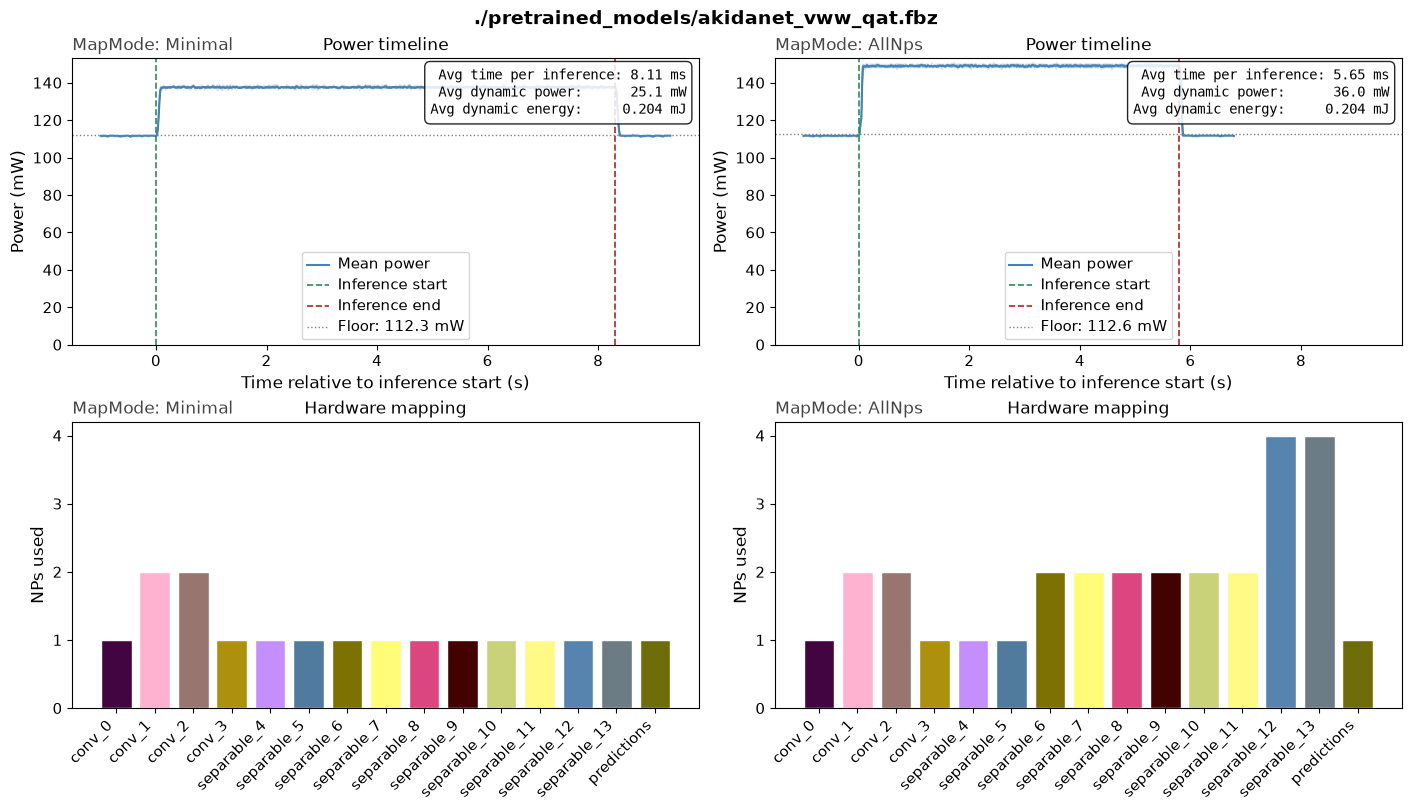

In [10]:
if device is not None:
    plot_full_model_results(full_results, akida_model, device,
                            model_name=akida_model_path)

### Per-Layer Benchmark

Full-model timing tells us the total cost but not where time is spent.
`per_layer_benchmark` from
[brainchip_utils/hardware_utils.py](../../../brainchip_utils/hardware_utils.py)
reconstructs latency layer by layer by running cumulative sub-models and
differencing the results.

Because Akida processes events (non-zero activations), a layer's cost is
proportional to its *input* sparsity: a layer receiving 90% sparse inputs has
far fewer events to process than one receiving 10% sparse inputs. The per-layer
timing and the sparsity values computed above are therefore naturally correlated —
low-sparsity layers are typically the latency bottlenecks.

In [11]:
from brainchip_utils.hardware_utils import per_layer_benchmark
from brainchip_utils.plot_utils import plot_per_layer_results

if device is not None:
    # Map without hw_only so akida_model.sequences is populated for the plot
    akida_model.map(device, mode=akida.MapMode.Minimal)

    print(f'Running per-layer benchmark ({len(samples)} samples)...')
    per_layer_results = per_layer_benchmark(akida_model, device, samples)

Running per-layer benchmark (1024 samples)...



Layer            Latency (ms)       Clocks
----------------------------------
conv_0                 0.1843
conv_1                 0.2244
conv_2                 0.8046
conv_3                 0.4928
separable_4            1.1966
separable_5            0.7249
separable_6            0.7689
separable_7            0.6940
separable_8            0.6021
separable_9            0.4765
separable_10           0.4228
separable_11           0.3235
separable_12           0.9412
separable_13           0.1573
predictions            0.0215
----------------------------------
Total                  8.0351


The plot stacks three panels: per-layer latency, input sparsity per layer, and
the hardware mapping. The inverse relationship between sparsity and latency is
the direct signature of the event-driven compute model: dense activations
generate more events, and more events mean more work for the hardware.

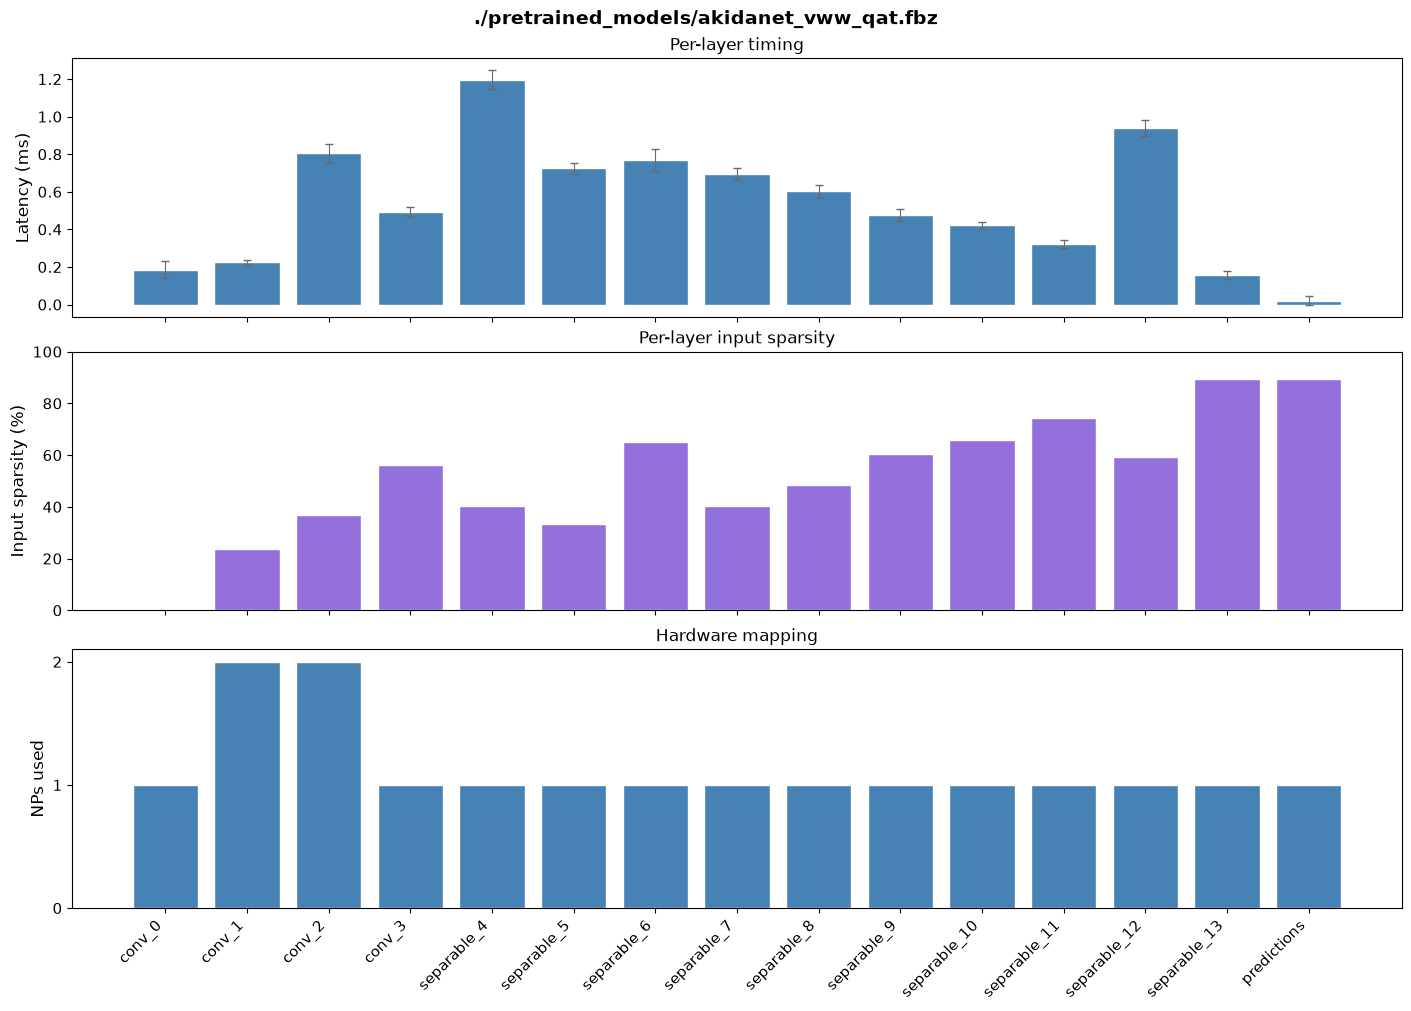

In [12]:
if device is not None:
    plot_per_layer_results(per_layer_results, akida_model, sparsity_dict,
                           model_name=akida_model_path)